In [44]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats
import statsmodels.api as sm
from scipy.stats import t as t_dist
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import joblib
import os
import re as re
import json
import zipfile

In [45]:
# Load feature_df_raw and feature_df_enc
with zipfile.ZipFile(f"../csv_outputs/feature_df_raw.zip") as zf:
    with zf.open("feature_df_raw.csv") as f:
        feature_df_raw = pd.read_csv(f)
with zipfile.ZipFile(f"../csv_outputs/feature_df_enc.zip") as zf:
    with zf.open("feature_df_enc.csv") as f:
        feature_df_enc = pd.read_csv(f)

# **1. Model training, validation & testing**

* Temporal train/validation/test split: 
  * Train on older data (<=2022) 
  * Validate on newer data (2023)
  * Test on newer data (2024-2025)

* Train and compare models based on the following loss functions: 
  * Lin-Lin/Pinball loss (asymmetric) with alpha=0.75
    * Penalise under-predictions more heavily (alpha>0.5) due to budget constraint
  * MSE (symmetric)

* Models:
  * Linear Regression
  * Random Forest (trained on MSE only, Lin-Lin loss is not supported)
  * LightGBM (trained on Lin-Lin and MSE)
  * XGBoost (trained on Lin-Lin and MSE)
  * CatBoost (trained on Lin-Lin and MSE)
  * Ensemble - combined forecasts 
    * Simple average (equal weights)
    * Optimised weights 

* Hyperparameter tuning: done using Optuna library

* Choosing the final prediction model: Diebold-Mariano (DM) Test
  * Compare symmetric vs asymmetric individual models (LightGBM, XGBoost, CatBoost)
  * Using the winning loss function, compare ensemble of models trained on that loss function vs the best-performing individual model
  * If ensemble wins, compare ensemble with vs without adding Random Forest (ie. test if adding a model trained on symmetric loss can balance the predictions of the models trained on asymmetric loss)
  * Using the winning ensemble combination, compare equal vs optimised weights 

**1a. Train/validation/test split**

In [46]:
TARGET = "real_price"
FEATURES = [c for c in feature_df_raw.columns if c not in (TARGET, "rpi")]

split_index = (2024 - 2017) * 12 # 84: test boundary (Jan 2024)
val_split = split_index - 12 # 72: last 12 months of train used as validation
test_upper = (2026 - 2017) * 12 # 108: Jan 2026 (held out as listings)

# Use raw (non-encoded) training data for XGBoost, CatBoost, LightGBM and baseline median models
train_df = feature_df_raw[feature_df_raw["month_index"] < val_split]
val_df = feature_df_raw[(feature_df_raw["month_index"] >= val_split) &
                        (feature_df_raw["month_index"] < split_index)]
test_df = feature_df_raw[(feature_df_raw["month_index"] >= split_index) & 
                         (feature_df_raw["month_index"] < test_upper)]
X_train_raw, X_val_raw, X_test_raw = train_df[FEATURES], val_df[FEATURES], test_df[FEATURES]
y_train, y_val, y_test = train_df[TARGET], val_df[TARGET], test_df[TARGET]

# CatBoost needs column indices for categorical features
cat_cols = ["town", "flat_type"]
cat_idx = [X_train_raw.columns.get_loc(c) for c in cat_cols]

# Split RPI arrays for conversion to nominal values
rpi_train, rpi_val, rpi_test = train_df["rpi"].values, val_df["rpi"].values, test_df["rpi"].values

RPI_BASE = 100.0
print(f"RPI range in data: {feature_df_raw["rpi"].min():.1f} – {feature_df_raw["rpi"].max():.1f}")

# Use encoded training data for Random Forest (cannot handle string categoricals natively)
train_df_enc = feature_df_enc[feature_df_enc["month_index"] < val_split]
val_df_enc = feature_df_enc[(feature_df_enc["month_index"] >= val_split) &
                               (feature_df_enc["month_index"] < split_index)]
test_df_enc = feature_df_enc[(feature_df_enc["month_index"] >= split_index) &
                             (feature_df_enc["month_index"] < test_upper)]
X_train_enc, X_val_enc, X_test_enc = train_df_enc[FEATURES], val_df_enc[FEATURES], test_df_enc[FEATURES]

print(f"Train: {len(X_train_enc):,} | Val: {len(X_val_enc):,} | Test: {len(X_test_enc):,}")

# Combine training + validation set to refit the final model after hyperparameter tuning
X_trainval_raw = pd.concat([X_train_raw, X_val_raw]).reset_index(drop=True)
X_trainval = pd.concat([X_train_enc, X_val_enc]).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val]).reset_index(drop=True)

for col in cat_cols:
    X_train_raw[col] = X_train_raw[col].astype("category")
    X_val_raw[col] = X_val_raw[col].astype("category")
    X_test_raw[col] = X_test_raw[col].astype("category")
    X_trainval_raw[col] = X_trainval_raw[col].astype("category")

RPI range in data: 130.8 – 203.7
Train: 143,396 | Val: 25,754 | Test: 52,918


**1b. Loss function & Alpha selection**

The asymmetric Lin-Lin (pinball) loss penalises under- and over-predictions differently:

$$L(e,\alpha) = \begin{cases} \alpha \cdot e & \text{if } e \geq 0 \quad \text{(under-prediction)} \\ (1-\alpha) \cdot |e| & \text{if } e < 0 \quad \text{(over-prediction)} \end{cases}$$

where $\alpha = c_{\text{under}} / (c_{\text{under}} + c_{\text{over}})$ and $e = y_{\text{true}} - \hat{y}$.

**Choosing $\alpha$ in the HDB buyer context:**
- **Under-prediction** ($\hat{y} < \text{actual}$): buyer's budget may be insufficient: more costly
- **Over-prediction** ($\hat{y} > \text{actual}$): within buyer's budget: less costly, but makes flat search slightly more inefficient

As the relative severity of over- vs under-prediction in this context is subjective and there are no defined cost functions, we assume under-prediction is 3x as costly as over-prediction, since buyers would not want to exceed their budget. This is validated (but not determined) by checking that empirical coverage $\approx$ 0.75 on the validation set.

Training objectives:

| Variant | Models | Loss function |
|---|---|---|
| Asymmetric | LightGBM, XGBoost, CatBoost | Lin-Lin loss with $\alpha$ = 0.5 |
| Symmetric | Random Forest*, LightGBM, XGBoost, CatBoost | MSE/RMSE |

*Random Forest is only trained on symmetric loss as asymmetric Lin-Lin loss is not supported

In [47]:
ALPHA = 0.75 # asymmetric: c_under = 3 × c_over

def linlin_loss(y_true, y_pred, alpha=ALPHA):
    errors = y_true - y_pred
    loss = np.where(errors >= 0, alpha * errors, (1 - alpha) * (-errors))
    return loss, loss.mean()

**1c. Model training & hyperparameter tuning**

In [48]:
def to_nominal(real_pred, rpi_series, rpi_base=RPI_BASE):
    return np.array(real_pred) * (np.array(rpi_series) / rpi_base)

def evaluate(name, y_true, y_pred, rpi_series, alpha=ALPHA):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    errors = y_true - y_pred
    linlin = np.mean(np.where(errors >= 0, alpha * errors, (1 - alpha) * (-errors)))
    cov = np.mean(y_true <= y_pred)
    nominal_mae = mean_absolute_error(
        to_nominal(y_true, rpi_series),
        to_nominal(y_pred, rpi_series)
    )
    print(f"\n{name} (alpha={alpha})")
    print(f"Lin-Lin: {linlin:,.0f}")
    print(f"Coverage: {cov:.3f}")
    print(f"MAE (nominal $): ${nominal_mae:,.0f}")
    print(f"RMSE (real $): ${rmse:,.0f}")
    print(f"MAPE: {mape:.2f}%")
    return {"name": name, "Lin-Lin": linlin, "Coverage": cov,
            "MAE_nominal": nominal_mae, "MAE": mae, "RMSE": rmse, "MAPE": mape}

In [49]:
# Benchmarks
## Global Median
overall_train_median = train_df[TARGET].median()
global_median_pred = np.full(len(y_test), overall_train_median)
res_global_median = evaluate("Global Median", y_test, global_median_pred, rpi_test)

## Stratified Median (town x flat_type)
group_median_map = (
    train_df.groupby(["town", "flat_type"])[TARGET]
    .median().rename("group_median")
)
stratified_median = (
    test_df[["town", "flat_type"]]
    .join(group_median_map, on=["town", "flat_type"])
    ["group_median"].fillna(overall_train_median).values
)
res_strat_median = evaluate("Stratified Median (town x flat_type)", y_test, stratified_median, rpi_test)


Global Median (alpha=0.75)
Lin-Lin: 39,917
Coverage: 0.524
MAE (nominal $): $149,876
RMSE (real $): $99,816
MAPE: 25.42%

Stratified Median (town x flat_type) (alpha=0.75)
Lin-Lin: 20,230
Coverage: 0.504
MAE (nominal $): $75,692
RMSE (real $): $55,994
MAPE: 11.75%


In [51]:
# Linear Regression (Ridge): symmetric baseline
# No quantile variant exists. Evaluated on both symmetric and asymmetric metrics.

## Validation: fit scaler on train only
scaler_val = StandardScaler()
X_train_scaled = scaler_val.fit_transform(X_train_enc)
X_val_scaled = scaler_val.transform(X_val_enc)

lr_val_model = Ridge(alpha=1.0)
lr_val_model.fit(X_train_scaled, y_train) # train on training set only
lr_val_pred = lr_val_model.predict(X_val_scaled) # predict val

## Final: refit scaler on full train+val
scaler_final = StandardScaler()
X_trainval_scaled = scaler_final.fit_transform(X_trainval) # train on train+val
X_test_scaled = scaler_final.transform(X_test_enc)

lr_model = Ridge(alpha=1.0)
lr_model.fit(X_trainval_scaled, y_trainval)
lr_test_pred = lr_model.predict(X_test_scaled)

res_lr = evaluate("Linear Regression (Ridge)", y_test, lr_test_pred, rpi_test)

from sklearn.metrics import r2_score
r2 = r2_score(y_test, lr_test_pred)
n = len(y_test)
p = X_test_scaled.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1)/(n - p - 1)
print(f"R2: {r2}")
print(f"Adjusted R2: {adj_r2}")


Linear Regression (Ridge) (alpha=0.75)
Lin-Lin: 15,370
Coverage: 0.519
MAE (nominal $): $60,257
RMSE (real $): $39,560
MAPE: 10.36%
R2: 0.8421407317588016
Adjusted R2: 0.8420332653028593


In [ ]:
# Random Forest: Symmetric loss only 
# RF cannot use quantile/LinLin loss natively
optuna.logging.set_verbosity(optuna.logging.WARNING)

def rf_objective(trial):
    model = RandomForestRegressor(
        n_estimators=80,
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 3, 12),
        max_features=trial.suggest_float("max_features", 0.3, 0.7),
        max_depth=trial.suggest_int("max_depth", 8, 20),
        n_jobs=-1, random_state=42
    )
    model.fit(X_train_enc, y_train)
    return mean_absolute_error(y_val, model.predict(X_val_enc))

rf_study = optuna.create_study(direction="minimize",
                               sampler=optuna.samplers.TPESampler(seed=42, multivariate=True))
rf_study.optimize(rf_objective, n_trials=15, show_progress_bar=True)
print("Best RF params:", rf_study.best_params)

rf_model_val = RandomForestRegressor(n_estimators=400, **rf_study.best_params,
                                     n_jobs=-1, random_state=42)
rf_model_val.fit(X_train_enc, y_train)
rf_val_pred = rf_model_val.predict(X_val_enc)

rf_model = RandomForestRegressor(n_estimators=400, **rf_study.best_params,
                                 n_jobs=-1, random_state=42)
rf_model.fit(X_trainval, y_trainval)
rf_pred = rf_model.predict(X_test_enc)

res_rf = evaluate("Random Forest (Symmetric)", y_test, rf_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
Best trial: 14. Best value: 12645.3: 100%|██████████| 15/15 [09:20<00:00, 37.40s/it, 560.99/600 seconds]


Best RF params: {'min_samples_leaf': 3, 'max_features': 0.5454865080358684, 'max_depth': 19}

Random Forest (Symmetric) (alpha=0.75)
Lin-Lin: 5,710
Coverage: 0.591
MAE (nominal $): $25,648
RMSE (real $): $18,407
MAPE: 4.07%


In [ ]:
# LightGBM: Asymmetric variant 
def lgb_safe(df):
    df = df.copy()
    df.columns = [re.sub(r"[^A-Za-z0-9_]", "_", c) for c in df.columns]
    return df

X_train_lgb = lgb_safe(X_train_raw)
X_val_lgb = lgb_safe(X_val_raw)
X_test_lgb = lgb_safe(X_test_raw)
X_trainval_lgb = lgb_safe(X_trainval_raw)
cat_cols_lgb = [re.sub(r"[^A-Za-z0-9_]", "_", c) for c in cat_cols]

optuna.logging.set_verbosity(optuna.logging.WARNING)

def lgb_objective(trial):
    model = lgb.LGBMRegressor(
        n_estimators=2000,
        objective="quantile", alpha=ALPHA,
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        num_leaves=trial.suggest_int("num_leaves", 31, 127),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 80),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 15.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        random_state=42, n_jobs=-1
    )
    model.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)],
              categorical_feature=cat_cols_lgb,
              callbacks=[lgb.early_stopping(75), lgb.log_evaluation(0)])
    _, pl = linlin_loss(y_val.values, model.predict(X_val_lgb), ALPHA)
    return pl

lgb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
lgb_study.optimize(lgb_objective, n_trials=15, show_progress_bar=True)
print("Best LGB params:", lgb_study.best_params)

lgb_model_val = lgb.LGBMRegressor(
    n_estimators=2000, objective="quantile", alpha=ALPHA,
    **lgb_study.best_params, random_state=42, n_jobs=-1
)
lgb_model_val.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)],
                  categorical_feature=cat_cols_lgb,
                  callbacks=[lgb.early_stopping(75), lgb.log_evaluation(50)])
lgb_val_pred = lgb_model_val.predict(X_val_lgb)
best_lgb_iter = lgb_model_val.best_iteration_
print(f"Best LightGBM iteration: {best_lgb_iter}")

lgb_model = lgb.LGBMRegressor(
    n_estimators=best_lgb_iter, objective="quantile", alpha=ALPHA,
    **lgb_study.best_params, random_state=42, n_jobs=-1
)
lgb_model.fit(X_trainval_lgb, y_trainval, categorical_feature=cat_cols_lgb,
              callbacks=[lgb.log_evaluation(50)])
lgb_pred = lgb_model.predict(X_test_lgb)

res_lgb = evaluate("LightGBM (Asymmetric)", y_test, lgb_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
  0%|          | 0/15 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009529 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 392670.156250
Training until validation scores don't improve for 75 rounds
Did not meet early stopping. Best iteration is:
[1932]	valid_0's quantile: 4818.99


Best trial: 0. Best value: 4818.99:   7%|▋         | 1/15 [00:50<11:42, 50.21s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021708 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 392670.156250
Training until validation scores don't improve for 75 rounds
Early stopping, best iteration is:
[748]	valid_0's quantile: 4939.41


Best trial: 0. Best value: 4818.99:  13%|█▎        | 2/15 [01:09<06:59, 32.24s/it]

...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002357 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 392670.156250
Training until validation scores don't improve for 75 rounds
Did not meet early stopping. Best iteration is:
[1992]	valid_0's quantile: 4772.33


Best trial: 11. Best value: 4749.07:  93%|█████████▎| 14/15 [08:59<00:40, 40.50s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016273 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 392670.156250
Training until validation scores don't improve for 75 rounds
Did not meet early stopping. Best iteration is:
[1999]	valid_0's quantile: 4817.63


Best trial: 11. Best value: 4749.07: 100%|██████████| 15/15 [09:43<00:00, 38.87s/it]


Best LGB params: {'learning_rate': 0.04314878687306059, 'num_leaves': 103, 'min_child_samples': 20, 'subsample': 0.9607903966782164, 'colsample_bytree': 0.5340184833000602, 'reg_lambda': 1.1619496046220776, 'reg_alpha': 0.004608234147476909}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019566 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 392670.156250
Training until validation scores don't improve for 75 rounds
[50]	valid_0's quantile: 9336.16
[100]	valid_0's quantile: 6209.38
[150]	valid_0's quantile: 5478.83
[200]	valid_0's quantile: 5241.1
[250]	valid_0's quantile: 5124.27
[300]	valid_0's quantile: 5042.26
[350]	valid_0's quantile: 4991.22
[400]	valid_0's quantile: 4954.06
[450]	valid_0's quantile: 4926.71
[500]	valid_0's quantile: 4903.85
[550]	valid

In [78]:
# LightGBM: Symmetric variant
optuna.logging.set_verbosity(optuna.logging.WARNING)

def lgb_sym_objective(trial):
    model = lgb.LGBMRegressor(
        n_estimators=2000,
        objective="regression",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        num_leaves=trial.suggest_int("num_leaves", 31, 127),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 80),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 15.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        random_state=42, n_jobs=-1
    )
    model.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)],
              categorical_feature=cat_cols_lgb,
              callbacks=[lgb.early_stopping(75), lgb.log_evaluation(0)])
    return mean_absolute_error(y_val, model.predict(X_val_lgb))

lgb_sym_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
lgb_sym_study.optimize(lgb_sym_objective, n_trials=15, show_progress_bar=True)
print("Best LGB sym params:", lgb_sym_study.best_params)

lgb_sym_model_val = lgb.LGBMRegressor(
    n_estimators=2000, objective="regression",
    **lgb_sym_study.best_params, random_state=42, n_jobs=-1
)
lgb_sym_model_val.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)],
                      categorical_feature=cat_cols_lgb,
                      callbacks=[lgb.early_stopping(75), lgb.log_evaluation(50)])
lgb_sym_val_pred = lgb_sym_model_val.predict(X_val_lgb)
best_lgb_sym_iter = lgb_sym_model_val.best_iteration_

lgb_sym_model = lgb.LGBMRegressor(
    n_estimators=best_lgb_sym_iter, objective="regression",
    **lgb_sym_study.best_params, random_state=42, n_jobs=-1
)
lgb_sym_model.fit(X_trainval_lgb, y_trainval, categorical_feature=cat_cols_lgb,
                  callbacks=[lgb.log_evaluation(50)])
lgb_sym_pred = lgb_sym_model.predict(X_test_lgb)

res_lgb_sym = evaluate("LightGBM (Symmetric)", y_test, lgb_sym_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
  0%|          | 0/15 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017269 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 335309.553833
Training until validation scores don't improve for 75 rounds
Early stopping, best iteration is:
[1130]	valid_0's l2: 2.75794e+08


Best trial: 0. Best value: 11722.2:   7%|▋         | 1/15 [00:29<06:46, 29.03s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021240 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 335309.553833
Training until validation scores don't improve for 75 rounds
Early stopping, best iteration is:
[508]	valid_0's l2: 3.05236e+08


Best trial: 0. Best value: 11722.2:  13%|█▎        | 2/15 [00:50<05:17, 24.45s/it]

...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024747 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 335309.553833
Training until validation scores don't improve for 75 rounds
Early stopping, best iteration is:
[1750]	valid_0's l2: 2.76754e+08


Best trial: 10. Best value: 11537.1:  93%|█████████▎| 14/15 [07:52<00:34, 34.37s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 335309.553833
Training until validation scores don't improve for 75 rounds
Did not meet early stopping. Best iteration is:
[1996]	valid_0's l2: 2.73751e+08


Best trial: 10. Best value: 11537.1: 100%|██████████| 15/15 [08:28<00:00, 33.89s/it]


Best LGB sym params: {'learning_rate': 0.034907905414608316, 'num_leaves': 118, 'min_child_samples': 70, 'subsample': 0.8737239523738184, 'colsample_bytree': 0.5347932177377854, 'reg_lambda': 0.8392491702129204, 'reg_alpha': 0.00010850871665981005}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013784 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6769
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 36
[LightGBM] [Info] Start training from score 335309.553833
Training until validation scores don't improve for 75 rounds
[50]	valid_0's l2: 8.32546e+08
[100]	valid_0's l2: 4.10412e+08
[150]	valid_0's l2: 3.59065e+08
[200]	valid_0's l2: 3.37346e+08
[250]	valid_0's l2: 3.20091e+08
[300]	valid_0's l2: 3.08195e+08
[350]	valid_0's l2: 2.98977e+08
[400]	valid_0's l2: 2.92755e+08
[450]	valid_0's l2: 2.88815e+08
[500]	valid_0's l2: 2.86233e+08
[550]	valid_0's l2: 2.8

In [ ]:
# XGBoost: Asymmetric
optuna.logging.set_verbosity(optuna.logging.WARNING)

def xgb_objective(trial):
    model = xgb.XGBRegressor(
        n_estimators=2000, 
        objective="reg:quantileerror", quantile_alpha=ALPHA,
        enable_categorical=True, tree_method="hist",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        max_depth=trial.suggest_int("max_depth", 4, 8),
        min_child_weight=trial.suggest_int("min_child_weight", 5, 30),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 15.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        random_state=42, n_jobs=-1, early_stopping_rounds=75 
    )
    model.fit(X_train_raw, y_train, eval_set=[(X_val_raw, y_val)], verbose=False)
    _, pl = linlin_loss(y_val.values, model.predict(X_val_raw), ALPHA)
    return pl

xgb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
xgb_study.optimize(xgb_objective, n_trials=15, show_progress_bar=True) 
xgb_model_val = xgb.XGBRegressor(
    n_estimators=2000, objective="reg:quantileerror", quantile_alpha=ALPHA,
    enable_categorical=True, tree_method="hist",
    **xgb_study.best_params, random_state=42, n_jobs=-1, early_stopping_rounds=75)
xgb_model_val.fit(X_train_raw, y_train, eval_set=[(X_val_raw, y_val)], verbose=50)
print(f"Best iteration: {xgb_model_val.best_iteration}")
xgb_val_pred = xgb_model_val.predict(X_val_raw)

best_xgb_params = {k: v for k, v in xgb_study.best_params.items()
                   if k != "early_stopping_rounds"}
xgb_model = xgb.XGBRegressor(
    n_estimators=xgb_model_val.best_iteration + 1,
    objective="reg:quantileerror", quantile_alpha=ALPHA,
    enable_categorical=True, tree_method="hist",
    **best_xgb_params, random_state=42, n_jobs=-1)
xgb_model.fit(X_trainval_raw, y_trainval, verbose=50)
xgb_pred = xgb_model.predict(X_test_raw)

res_xgb = evaluate("XGBoost (Asymmetric)", y_test, xgb_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
Best trial: 10. Best value: 4701.69: 100%|██████████| 15/15 [29:39<00:00, 118.64s/it]


[0]	validation_0-quantile:32965.01624
[50]	validation_0-quantile:10303.53251
[100]	validation_0-quantile:6405.65744
[150]	validation_0-quantile:5520.23160
[200]	validation_0-quantile:5280.25070
[250]	validation_0-quantile:5159.45244
[300]	validation_0-quantile:5058.48901
[350]	validation_0-quantile:4987.35580
[400]	validation_0-quantile:4939.67841
[450]	validation_0-quantile:4899.14867
[500]	validation_0-quantile:4871.54983
[550]	validation_0-quantile:4852.58157
[600]	validation_0-quantile:4832.94948
[650]	validation_0-quantile:4809.87886
[700]	validation_0-quantile:4795.45098
[750]	validation_0-quantile:4786.51015
[800]	validation_0-quantile:4776.77513
[850]	validation_0-quantile:4768.78604
[900]	validation_0-quantile:4763.05470
[950]	validation_0-quantile:4756.95697
[1000]	validation_0-quantile:4748.87722
[1050]	validation_0-quantile:4746.19645
[1100]	validation_0-quantile:4736.94015
[1150]	validation_0-quantile:4731.97211
[1200]	validation_0-quantile:4730.30859
[1250]	validation_0-q

In [80]:
# XGBoost: Symmetric
optuna.logging.set_verbosity(optuna.logging.WARNING)

def xgb_sym_objective(trial):
    model = xgb.XGBRegressor(
        n_estimators=2000,
        objective="reg:squarederror",
        enable_categorical=True, tree_method="hist",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        max_depth=trial.suggest_int("max_depth", 4, 8),
        min_child_weight=trial.suggest_int("min_child_weight", 5, 30),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 15.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        random_state=42, n_jobs=-1, early_stopping_rounds=75
    )
    model.fit(X_train_raw, y_train, eval_set=[(X_val_raw, y_val)], verbose=False)
    return mean_absolute_error(y_val, model.predict(X_val_raw))

xgb_sym_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
xgb_sym_study.optimize(xgb_sym_objective, n_trials=15, show_progress_bar=True)

best_xgb_sym_params = {k: v for k, v in xgb_sym_study.best_params.items()
                       if k != "early_stopping_rounds"}

xgb_sym_model_val = xgb.XGBRegressor(
    n_estimators=2000, objective="reg:squarederror",
    enable_categorical=True, tree_method="hist",
    **best_xgb_sym_params, random_state=42, n_jobs=-1, early_stopping_rounds=75)
xgb_sym_model_val.fit(X_train_raw, y_train, eval_set=[(X_val_raw, y_val)], verbose=50)
xgb_sym_val_pred = xgb_sym_model_val.predict(X_val_raw)
best_xgb_sym_iter = xgb_sym_model_val.best_iteration

xgb_sym_model = xgb.XGBRegressor(
    n_estimators=best_xgb_sym_iter + 1, objective="reg:squarederror",
    enable_categorical=True, tree_method="hist",
    **best_xgb_sym_params, random_state=42, n_jobs=-1)
xgb_sym_model.fit(X_trainval_raw, y_trainval, verbose=50)
xgb_sym_pred = xgb_sym_model.predict(X_test_raw)

res_xgb_sym = evaluate("XGBoost (Symmetric)", y_test, xgb_sym_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
Best trial: 12. Best value: 11646.1: 100%|██████████| 15/15 [09:50<00:00, 39.39s/it]


[0]	validation_0-rmse:96030.89390
[50]	validation_0-rmse:29007.80651
[100]	validation_0-rmse:20044.40395
[150]	validation_0-rmse:18686.62461
[200]	validation_0-rmse:18153.64859
[250]	validation_0-rmse:17810.01242
[300]	validation_0-rmse:17558.61107
[350]	validation_0-rmse:17382.70732
[400]	validation_0-rmse:17236.91318
[450]	validation_0-rmse:17129.45586
[500]	validation_0-rmse:17037.88529
[550]	validation_0-rmse:16972.26677
[600]	validation_0-rmse:16888.83136
[650]	validation_0-rmse:16855.97657
[700]	validation_0-rmse:16824.32398
[750]	validation_0-rmse:16793.48272
[800]	validation_0-rmse:16763.10316
[850]	validation_0-rmse:16734.89009
[900]	validation_0-rmse:16717.69781
[950]	validation_0-rmse:16694.78668
[1000]	validation_0-rmse:16682.08548
[1050]	validation_0-rmse:16656.65502
[1100]	validation_0-rmse:16648.28882
[1150]	validation_0-rmse:16637.28911
[1200]	validation_0-rmse:16619.37873
[1250]	validation_0-rmse:16604.63631
[1300]	validation_0-rmse:16594.28958
[1350]	validation_0-rmse

In [ ]:
# CatBoost: Asymmetric
def cb_objective(trial):
    model = CatBoostRegressor(
        iterations=2000,                                         
        loss_function=f"Quantile:alpha={ALPHA}",
        eval_metric=f"Quantile:alpha={ALPHA}",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        depth=trial.suggest_int("depth", 4, 8),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 15.0, log=True),
        bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 1.0),
        rsm=trial.suggest_float("rsm", 0.5, 1.0),
        random_seed=42, verbose=False, early_stopping_rounds=75  
    )
    model.fit(X_train_raw, y_train, eval_set=(X_val_raw, y_val),
              cat_features=cat_idx, use_best_model=True)
    _, pl = linlin_loss(y_val.values, model.predict(X_val_raw), ALPHA)
    return pl

cb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
cb_study.optimize(cb_objective, n_trials=15, show_progress_bar=True)

cb_model_val = CatBoostRegressor(
    iterations=2000,
    loss_function=f"Quantile:alpha={ALPHA}", eval_metric=f"Quantile:alpha={ALPHA}",
    **cb_study.best_params, random_seed=42, verbose=200, early_stopping_rounds=75)
cb_model_val.fit(X_train_raw, y_train, eval_set=(X_val_raw, y_val),
                 cat_features=cat_idx, use_best_model=True)
cb_val_pred = cb_model_val.predict(X_val_raw)
best_cb_iter = cb_model_val.best_iteration_
print(f"Best CatBoost iteration: {best_cb_iter}")

cb_model = CatBoostRegressor(
    iterations=best_cb_iter + 1,
    loss_function=f"Quantile:alpha={ALPHA}", eval_metric=f"Quantile:alpha={ALPHA}",
    **cb_study.best_params, random_seed=42, verbose=200)
cb_model.fit(X_trainval_raw, y_trainval, cat_features=cat_idx)
cb_pred = cb_model.predict(X_test_raw)

res_cb = evaluate("CatBoost (Asymmetric)", y_test, cb_pred, rpi_test)

  0%|          | 0/15 [00:00<?, ?it/s]

Best trial: 0. Best value: 4763.55: 100%|██████████| 15/15 [1:15:17<00:00, 301.19s/it]


0:	learn: 37370.4683193	test: 32217.8188883	best: 32217.8188883 (0)	total: 159ms	remaining: 5m 16s
200:	learn: 6707.9395474	test: 6042.4449384	best: 6042.4449384 (200)	total: 51.8s	remaining: 7m 43s
400:	learn: 5668.0352430	test: 5350.3418771	best: 5350.3418771 (400)	total: 1m 36s	remaining: 6m 24s
600:	learn: 5260.1009807	test: 5077.3493672	best: 5077.3493672 (600)	total: 2m 24s	remaining: 5m 36s
800:	learn: 5021.1796831	test: 4945.2934829	best: 4945.2934829 (800)	total: 3m 13s	remaining: 4m 50s
1000:	learn: 4848.2041281	test: 4881.1567432	best: 4881.1567432 (1000)	total: 4m 1s	remaining: 4m
1200:	learn: 4712.3329886	test: 4833.3222849	best: 4833.2608056 (1198)	total: 4m 49s	remaining: 3m 12s
1400:	learn: 4604.7656006	test: 4803.2948011	best: 4803.2948011 (1400)	total: 5m 33s	remaining: 2m 22s
1600:	learn: 4513.1797667	test: 4782.9345085	best: 4782.9345085 (1600)	total: 6m 19s	remaining: 1m 34s
1800:	learn: 4436.1521930	test: 4771.6609837	best: 4771.3569020 (1787)	total: 7m 6s	remaini

In [76]:
# CatBoost: Symmetric
def cb_sym_objective(trial):
    model = CatBoostRegressor(
        iterations=2000,
        loss_function="RMSE",
        eval_metric="RMSE",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        depth=trial.suggest_int("depth", 4, 8),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 15.0, log=True),
        bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 1.0),
        rsm=trial.suggest_float("rsm", 0.5, 1.0),
        random_seed=42, verbose=False, early_stopping_rounds=75,
        thread_count=-1
    )
    model.fit(X_train_raw, y_train, eval_set=(X_val_raw, y_val),
              cat_features=cat_idx, use_best_model=True)
    return mean_absolute_error(y_val, model.predict(X_val_raw))

cb_sym_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
cb_sym_study.optimize(cb_sym_objective, n_trials=15, show_progress_bar=True)

cb_sym_model_val = CatBoostRegressor(
    iterations=2000, loss_function="RMSE", eval_metric="RMSE",
    **cb_sym_study.best_params, random_seed=42, verbose=200, early_stopping_rounds=75)
cb_sym_model_val.fit(X_train_raw, y_train, eval_set=(X_val_raw, y_val),
                     cat_features=cat_idx, use_best_model=True)
cb_sym_val_pred = cb_sym_model_val.predict(X_val_raw)
best_cb_sym_iter = cb_sym_model_val.best_iteration_

cb_sym_model = CatBoostRegressor(
    iterations=best_cb_sym_iter + 1, loss_function="RMSE", eval_metric="RMSE",
    **cb_sym_study.best_params, random_seed=42, verbose=200)
cb_sym_model.fit(X_trainval_raw, y_trainval, cat_features=cat_idx)
cb_sym_pred = cb_sym_model.predict(X_test_raw)

res_cb_sym = evaluate("CatBoost (Symmetric)", y_test, cb_sym_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
Best trial: 0. Best value: 11575.7: 100%|██████████| 15/15 [1:24:27<00:00, 337.83s/it]


0:	learn: 107391.4083205	test: 94086.1732407	best: 94086.1732407 (0)	total: 172ms	remaining: 5m 42s
200:	learn: 22530.2839114	test: 20386.9163599	best: 20386.9163599 (200)	total: 42.4s	remaining: 6m 19s
400:	learn: 19196.5154387	test: 18410.9283703	best: 18410.9283703 (400)	total: 1m 21s	remaining: 5m 26s
600:	learn: 18022.5635602	test: 17697.4531271	best: 17697.4531271 (600)	total: 2m 1s	remaining: 4m 43s
800:	learn: 17313.6861821	test: 17260.6364288	best: 17260.6364288 (800)	total: 2m 38s	remaining: 3m 57s
1000:	learn: 16837.2003542	test: 16996.0599113	best: 16996.0599113 (1000)	total: 3m 20s	remaining: 3m 20s
1200:	learn: 16446.9351608	test: 16790.8210389	best: 16790.8210389 (1200)	total: 4m	remaining: 2m 40s
1400:	learn: 16113.3583208	test: 16660.3621320	best: 16660.3621320 (1400)	total: 4m 54s	remaining: 2m 5s
1600:	learn: 15827.7783346	test: 16581.3912662	best: 16581.2883759 (1599)	total: 5m 47s	remaining: 1m 26s
1800:	learn: 15579.7613340	test: 16488.1730331	best: 16488.1730331 

# **2. Model evaluation**

* Diebold-Mariano test to choose the final model 
* Feature importances
* Comparison of model performance

In [105]:
import statsmodels.api as sm
from scipy.stats import t as t_dist
import matplotlib.pyplot as plt

DM_ALPHA = 0.05

def dm_test(y_true, pred1, pred2,
            groups=None, month_index=None,
            alpha=ALPHA, alternative="less",
            bonferroni_n=1, sig=DM_ALPHA,
            plot=True, label=""):
    """
    Diebold-Mariano test with:
    - Cluster-robust SEs by town, else standard OLS SE
    - Plot of d_t vs month_index to confirm stationarity of loss differentials 
    - Under-prediction calibration check for both predictions
    - Bonferroni correction on significance threshold
    
    H0: pred1 and pred2 are equally accurate 
    H1: pred1 is significantly more accurate than pred2 (one-sided test)
    """
    # Loss differential
    def pb(y, yhat):
        e = y - yhat
        return np.where(e >= 0, alpha * e, (alpha - 1) * e)

    d = pb(y_true, pred1) - pb(y_true, pred2)
    P = len(d)

    # Under-prediction calibration
    under1 = np.mean(pred1 < y_true)
    under2 = np.mean(pred2 < y_true)
    theoretical = 1.0 - alpha # optimal for Lin-Lin(alpha): underpredict (1-alpha) of the time

    # Diagnostic plot
    if plot and month_index is not None:
        months = np.asarray(month_index)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.scatter(months, d, alpha=0.07, s=8, color='gray', label='Individual Transactions')
        monthly_mean = pd.Series(d).groupby(months).mean()
        ax.plot(monthly_mean.index, monthly_mean.values, 'r-o', ms=4, label='Monthly Mean Diff')
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
        ax.set_xlabel('Month Index')
        ax.set_ylabel('Loss Differential (d_t)')
        title = f'DM Diagnostic: {label}' if label else 'DM Diagnostic'
        ax.set_title(title)
        ax.legend()
        plt.tight_layout()
        plt.show()

    # DM statistic (cluster-robust or standard)
    X = np.ones(P)
    if groups is not None:
        res = sm.OLS(d, X).fit(
            cov_type='cluster',
            cov_kwds={'groups': np.asarray(groups)}
        )
    else:
        res = sm.OLS(d, X).fit()

    t_stat = float(res.tvalues[0])
    df = float(res.df_resid)

    # One-sided p-value
    if alternative == "less":
        p_val = float(t_dist.cdf(t_stat, df=df))
    elif alternative == "greater":
        p_val = float(1 - t_dist.cdf(t_stat, df=df))
    else:  # two-sided
        p_val = float(2 * min(t_dist.cdf(t_stat, df=df), 1 - t_dist.cdf(t_stat, df=df)))

    # Bonferroni correction
    p_adj = min(p_val * bonferroni_n, 1.0)
    threshold = sig / bonferroni_n

    # Outcome
    significant = p_adj < sig # uses Bonferroni-adjusted p vs original threshold

    # Summary
    se_type = "cluster-robust (by town)" if groups is not None else "standard"
    print(f"SE type: {se_type}")
    print(f"Underpred rate: pred1={under1:.1%} | pred2={under2:.1%} (theoretical optimum={theoretical:.1%})")
    print(f"t={t_stat:.3f} | p={p_val:.4f} | adjusted p (Bonferroni n={bonferroni_n})={p_adj:.4f} | threshold={threshold:.4f}")
    if significant:
        print(f"--> Statistically significant: pred1 has lower expected {alpha}-Lin-Lin loss (H0 rejected).")
    else:
        print(f"--> Not statistically significant: cannot reject equal predictive ability (H0 is not rejected).")

    return t_stat, p_val, significant

Test 1: Asymmetric vs Symmetric (LightGBM, XGBoost, CatBoost)
H0: E[L(asym)] = E[L(sym)]
vs H1: E[L(asym)] < E[L(sym)]

LightGBM | Lin-Lin: Asymmetric = 4,875.8 | Symmetric = 5,239.0


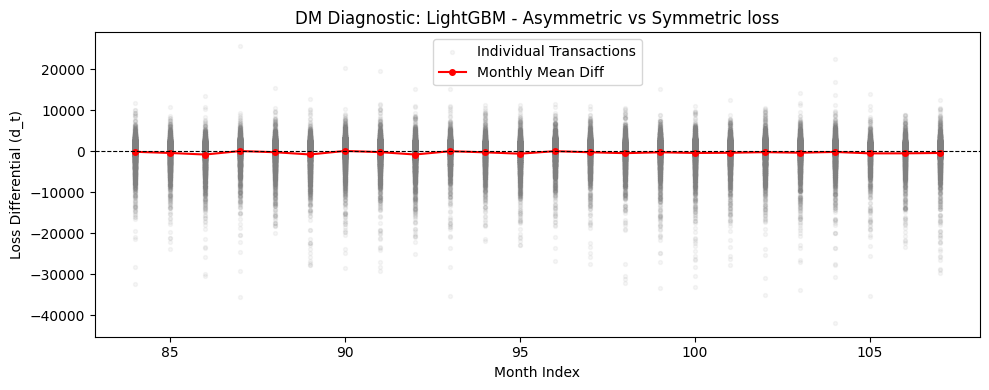

SE type: cluster-robust (by town)
Underpred rate: pred1=25.6% | pred2=40.1% (theoretical optimum=25.0%)
t=-3.889 | p=0.0001 | adjusted p (Bonferroni n=3)=0.0002 | threshold=0.0167
--> Statistically significant: pred1 has lower expected 0.75-Lin-Lin loss (H0 rejected).

XGBoost | Lin-Lin: Asymmetric = 4,881.8 | Symmetric = 5,234.5


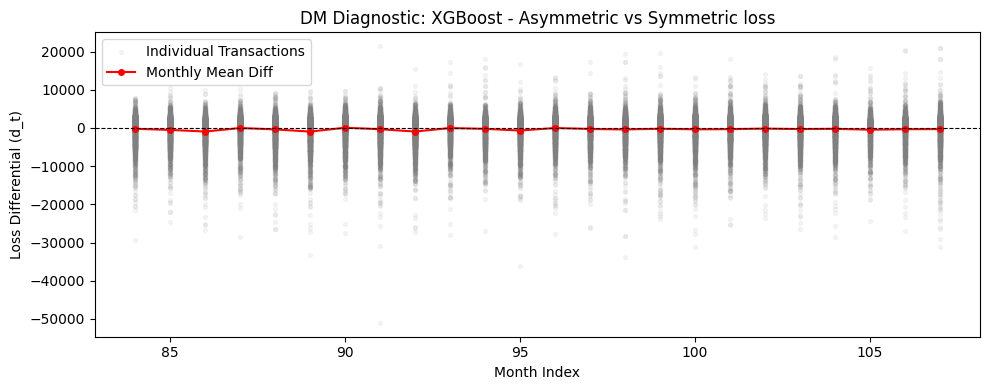

SE type: cluster-robust (by town)
Underpred rate: pred1=24.2% | pred2=40.7% (theoretical optimum=25.0%)
t=-3.234 | p=0.0006 | adjusted p (Bonferroni n=3)=0.0018 | threshold=0.0167
--> Statistically significant: pred1 has lower expected 0.75-Lin-Lin loss (H0 rejected).

CatBoost | Lin-Lin: Asymmetric = 4,845.8 | Symmetric = 5,305.0


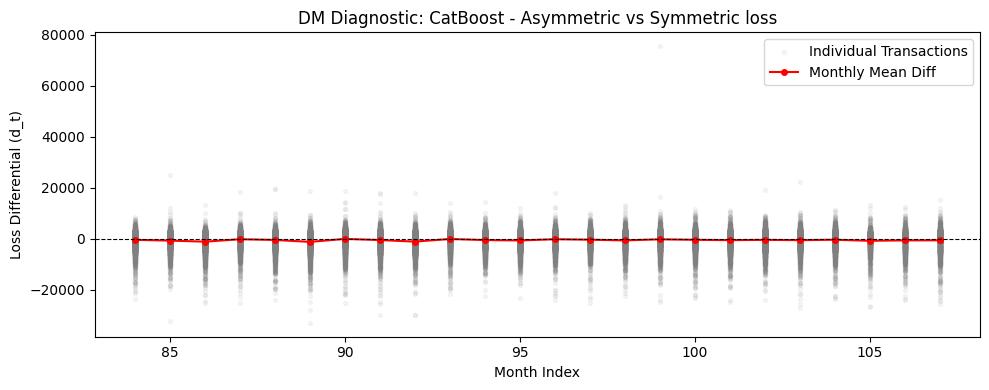

SE type: cluster-robust (by town)
Underpred rate: pred1=24.4% | pred2=42.0% (theoretical optimum=25.0%)
t=-4.708 | p=0.0000 | adjusted p (Bonferroni n=3)=0.0000 | threshold=0.0167
--> Statistically significant: pred1 has lower expected 0.75-Lin-Lin loss (H0 rejected).


In [106]:
y_test_arr = y_test.values

# Test 1: Asymmetric vs symmetric loss for individual models

test_1_candidates = [
    ("LightGBM", lgb_pred, lgb_sym_pred, lgb_val_pred, lgb_sym_val_pred, lgb_model, lgb_sym_model),
    ("XGBoost",  xgb_pred, xgb_sym_pred, xgb_val_pred, xgb_sym_val_pred, xgb_model, xgb_sym_model),
    ("CatBoost", cb_pred,  cb_sym_pred,  cb_val_pred,  cb_sym_val_pred,  cb_model,  cb_sym_model),
]

winners_pred = {}; winners_val_pred = {}; winners_model = {}

print("=" * 60)
print("Test 1: Asymmetric vs Symmetric (LightGBM, XGBoost, CatBoost)")
print("=" * 60)
print("H0: E[L(asym)] = E[L(sym)]")
print("vs H1: E[L(asym)] < E[L(sym)]")

for name, asym_p, sym_p, asym_v, sym_v, asym_m, sym_m in test_1_candidates:
    pb_asym = linlin_loss(y_test_arr, asym_p)[1]
    pb_sym = linlin_loss(y_test_arr, sym_p)[1]
    print(f"\n{name} | Lin-Lin: Asymmetric = {pb_asym:,.1f} | Symmetric = {pb_sym:,.1f}")
    t, p, significant = dm_test(
        y_test_arr, asym_p, sym_p,
        groups=test_df['town'], month_index=test_df['month_index'],
        bonferroni_n=3, label=f"{name} - Asymmetric vs Symmetric loss"
    )
    if significant:
        winners_pred[name] = asym_p
        winners_val_pred[name] = asym_v
        winners_model[name] = asym_m
    else:
        winners_pred[name] = sym_p
        winners_val_pred[name] = sym_v
        winners_model[name] = sym_m

Test 2: Ensemble vs Best individual model
H0: E[L(ensemble)] = E[L(best individual)]
vs H1: E[L(ensemble)] < E[L(best individual)]


Ensemble Lin-Lin loss: 4,767.9
Best individual model (CatBoost): 4,845.8


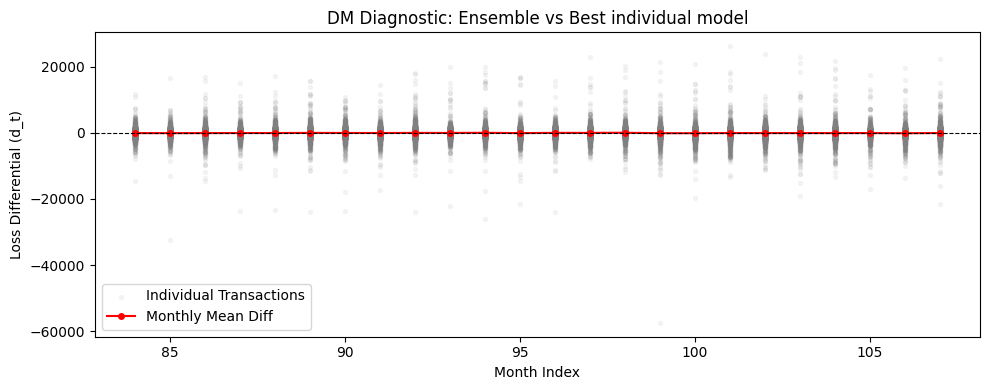

SE type: cluster-robust (by town)
Underpred rate: pred1=24.1% | pred2=24.4% (theoretical optimum=25.0%)
t=-3.293 | p=0.0005 | adjusted p (Bonferroni n=1)=0.0005 | threshold=0.0500
--> Statistically significant: pred1 has lower expected 0.75-Lin-Lin loss (H0 rejected).
--> Proceeding with ensemble.

Ensemble (boosting, equal weights) (alpha=0.75)
Lin-Lin: 4,768
Coverage: 0.759
MAE (nominal $): $28,176
RMSE (real $): $19,450
MAPE: 4.52%


In [ ]:
# Test 2: Ensemble vs best individual model

w_preds = list(winners_pred.values())
w_names = list(winners_pred.keys())

ens_b_pred = np.stack(w_preds, axis=1).mean(axis=1)
ens_b_val = np.stack(list(winners_val_pred.values()), axis=1).mean(axis=1)

pb_individuals = {n: linlin_loss(y_test_arr, p)[1] for n, p in winners_pred.items()}
best_ind_name = min(pb_individuals, key=pb_individuals.get)
best_ind_pred = winners_pred[best_ind_name]

pb_ens_b = linlin_loss(y_test_arr, ens_b_pred)[1]
pb_best_ind = pb_individuals[best_ind_name]

print("=" * 60)
print("Test 2: Ensemble vs Best individual model")
print("=" * 60)
print("H0: E[L(ensemble)] = E[L(best individual)]")
print("vs H1: E[L(ensemble)] < E[L(best individual)]")
print("\n")
print(f"Ensemble Lin-Lin loss: {pb_ens_b:,.1f}")
print(f"Best individual model ({best_ind_name}): {pb_best_ind:,.1f}")

t, p, significant = dm_test(
    y_test_arr, ens_b_pred, best_ind_pred,
    groups=test_df['town'], month_index=test_df['month_index'],
    bonferroni_n=1, label="Ensemble vs Best individual model"
)
stage_b_ensemble_wins = significant

if stage_b_ensemble_wins:
    current_pred = ens_b_pred
    current_val_pred = ens_b_val
    current_names = w_names.copy()
    print("--> Proceeding with ensemble.")
else:
    current_pred = best_ind_pred
    current_val_pred = winners_val_pred[best_ind_name]
    current_names = [best_ind_name]
    print("--> No improvement from ensemble, retaining best individual model.")

res_ens_b = evaluate("Ensemble (boosting, equal weights)", y_test, ens_b_pred, rpi_test)
ens_boosting_pred = ens_b_pred

Test 3: Ensemble+RF vs Ensemble (without RF)
H0: E[L(ensemble + RF)] = E[L(ensemble, no RF)]
vs H1: E[L(ensemble + RF)] < E[L(ensemble, no RF)]


Ensemble (no RF) Lin-Lin loss: 4,767.9
Ensemble + RF Lin-Lin loss: 4,802.3


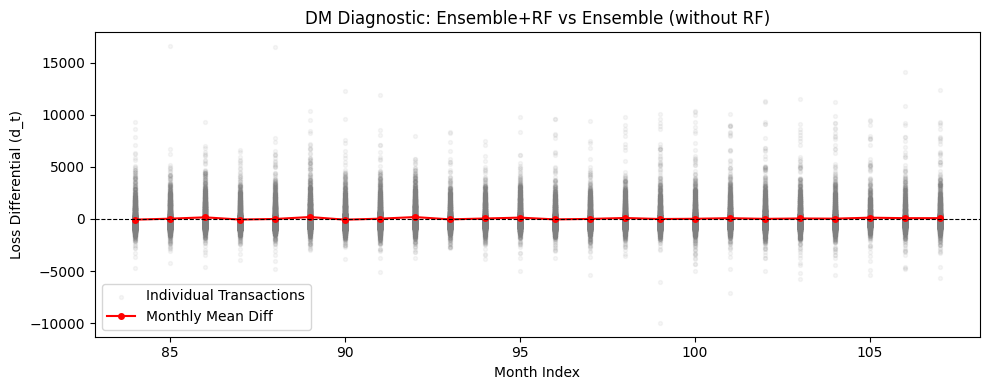

SE type: cluster-robust (by town)
Underpred rate: pred1=27.6% | pred2=24.1% (theoretical optimum=25.0%)
t=1.478 | p=0.9303 | adjusted p (Bonferroni n=1)=0.9303 | threshold=0.0500
--> Not statistically significant: cannot reject equal predictive ability (H0 is not rejected).
--> RF does not improve ensemble, we exclude RF.

Ensemble (boosting+RF, equal weights) (alpha=0.75)
Lin-Lin: 4,802
Coverage: 0.724
MAE (nominal $): $26,755
RMSE (real $): $18,686
MAPE: 4.29%


In [ ]:
# Test 3: Ensemble without RF vs with RF 
ens_c_used = False
res_ens_c = None
if stage_b_ensemble_wins:
    ens_c_pred = np.stack(w_preds + [rf_pred], axis=1).mean(axis=1)
    ens_c_val = np.stack(list(winners_val_pred.values()) + [rf_val_pred], axis=1).mean(axis=1)

    pb_ens_c = linlin_loss(y_test_arr, ens_c_pred)[1]
    print("=" * 60)
    print("Test 3: Ensemble+RF vs Ensemble (without RF)")
    print("=" * 60)
    print("H0: E[L(ensemble + RF)] = E[L(ensemble, no RF)]")
    print("vs H1: E[L(ensemble + RF)] < E[L(ensemble, no RF)]")
    print("\n")
    print(f"Ensemble (no RF) Lin-Lin loss: {pb_ens_b:,.1f}")
    print(f"Ensemble + RF Lin-Lin loss: {pb_ens_c:,.1f}")

    t, p, significant = dm_test(
        y_test_arr, ens_c_pred, current_pred,
        groups=test_df['town'], month_index=test_df['month_index'],
        bonferroni_n=1, label="Ensemble+RF vs Ensemble (without RF)"
    )
    ens_c_used = significant
    if significant:
        current_pred = ens_c_pred
        current_val_pred = ens_c_val
        current_names = w_names + ["RandomForest"]
        print("--> RF improves ensemble, we include RF.")
    else:
        print("--> RF does not improve ensemble, we exclude RF.")

    res_ens_c = evaluate("Ensemble (boosting+RF, equal weights)", y_test, ens_c_pred, rpi_test)
else:
    ens_c_used = False
    print("Test 3: Skipped (individual model won Test 2)")

Test 4: Optimised Weights vs Equal Weights
H0: E[L(ensemble, optimised weights] = E[L(ensemble, equal weights)]
vs H1: E[L(ensemble, optimised weights)] < E[L(ensemble, equal weights)]


Optimised weights Lin-Lin loss: 4,769.5
Equal weights Lin-Lin loss: 4,767.9


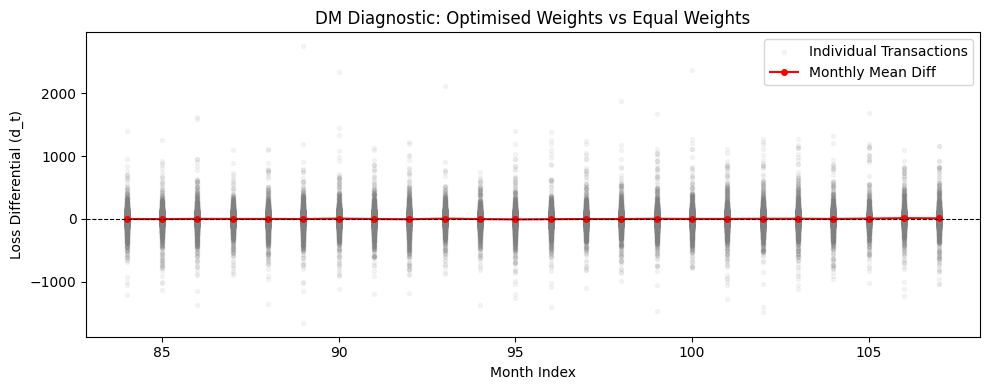

SE type: cluster-robust (by town)
Underpred rate: pred1=24.0% | pred2=24.1% (theoretical optimum=25.0%)
t=0.657 | p=0.7444 | adjusted p (Bonferroni n=1)=0.7444 | threshold=0.0500
--> Not statistically significant: cannot reject equal predictive ability (H0 is not rejected).

Ensemble (optimised weights) (alpha=0.75)
Lin-Lin: 4,769
Coverage: 0.760
MAE (nominal $): $28,221
RMSE (real $): $19,474
MAPE: 4.53%


In [109]:
# Test 4: Ensemble with optimised weights vs equal weights
if stage_b_ensemble_wins:
    val_preds_list  = [winners_val_pred[n] for n in w_names]
    test_preds_list = [winners_pred[n] for n in w_names]
    if "RandomForest" in current_names:
        val_preds_list  += [rf_val_pred]
        test_preds_list += [rf_pred]

    stacked_val = np.stack(val_preds_list,  axis=1)
    stacked_test = np.stack(test_preds_list, axis=1)
    n_models = stacked_val.shape[1]

    def ens_linlin(w):
        return linlin_loss(y_val.values, stacked_val @ w)[1]

    result = minimize(
        ens_linlin,
        x0=np.ones(n_models) / n_models,
        method="SLSQP",
        bounds=[(0, 1)] * n_models,
        constraints={"type": "eq", "fun": lambda w: w.sum() - 1}
    )
    opt_weights = result.x
    opt_pred = stacked_test @ opt_weights
    equal_pred = stacked_test.mean(axis=1)
    equal_weights = np.ones(n_models) / n_models

    pb_opt = linlin_loss(y_test_arr, opt_pred)[1]
    pb_equal = linlin_loss(y_test_arr, equal_pred)[1]
    print("=" * 60)
    print("Test 4: Optimised Weights vs Equal Weights")
    print("=" * 60)
    print("H0: E[L(ensemble, optimised weights] = E[L(ensemble, equal weights)]")
    print("vs H1: E[L(ensemble, optimised weights)] < E[L(ensemble, equal weights)]")
    print("\n")
    print(f"Optimised weights Lin-Lin loss: {pb_opt:,.1f}")
    print(f"Equal weights Lin-Lin loss: {pb_equal:,.1f}")

    t, p, significant = dm_test(
        y_test_arr, opt_pred, equal_pred,
        groups=test_df['town'], month_index=test_df['month_index'],
        bonferroni_n=1, label="Optimised Weights vs Equal Weights"
    )
    if significant:
        final_pred = opt_pred
        final_weights = opt_weights
        final_weights_label = "optimised"
    else:
        final_pred = equal_pred
        final_weights = equal_weights
        final_weights_label = "equal"

    res_ens_opt = evaluate("Ensemble (optimised weights)", y_test, opt_pred, rpi_test)
else:
    final_pred = current_pred
    final_weights = np.array([1.0])
    final_weights_label = "equal"
    equal_pred = current_pred

final_model_names = current_names

In [ ]:
# Final Model Summary
print("=" * 55)
print("FINAL MODEL SELECTION SUMMARY")
print("=" * 55)
print(f"Loss function: Lin-Lin (alpha={ALPHA})")
print(f"SE correction: Cluster-robust by town")
print(f"Bonferroni (Test 1): n=3, threshold={DM_ALPHA/3:.4f}")
print()
print(f"Test 1: Asymmetric wins over Symmetric for all 3 base models")
print(f"Test 2: Ensemble beats best individual ({best_ind_name})")
print(f"Test 3: RF {'included' if ens_c_used else 'excluded'} from ensemble")
print(f"Test 4: {final_weights_label.capitalize()} weights selected")
print()
print(f"FINAL MODEL: {len(current_names)}-model ensemble")
print(f"Components: {', '.join(current_names)}")
print(f"Weights: {final_weights_label}")
print(f"Underpred %: {np.mean(final_pred < y_test_arr):.1%} (target: {1-ALPHA:.1%})")
print("=" * 55)

FINAL MODEL SELECTION SUMMARY
Loss function: Lin-Lin (alpha=0.75)
SE correction: Cluster-robust by town
Bonferroni (Test 1): n=3, threshold=0.0167

Test 1: Asymmetric wins over Symmetric for all 3 base models
Test 2: Ensemble beats best individual (CatBoost)
Test 3: RF excluded from ensemble
Test 4: Equal weights selected

FINAL MODEL: 3-model ensemble
Components: LightGBM, XGBoost, CatBoost
Weights: equal
Underpred %: 24.1% (target: 25.0%)


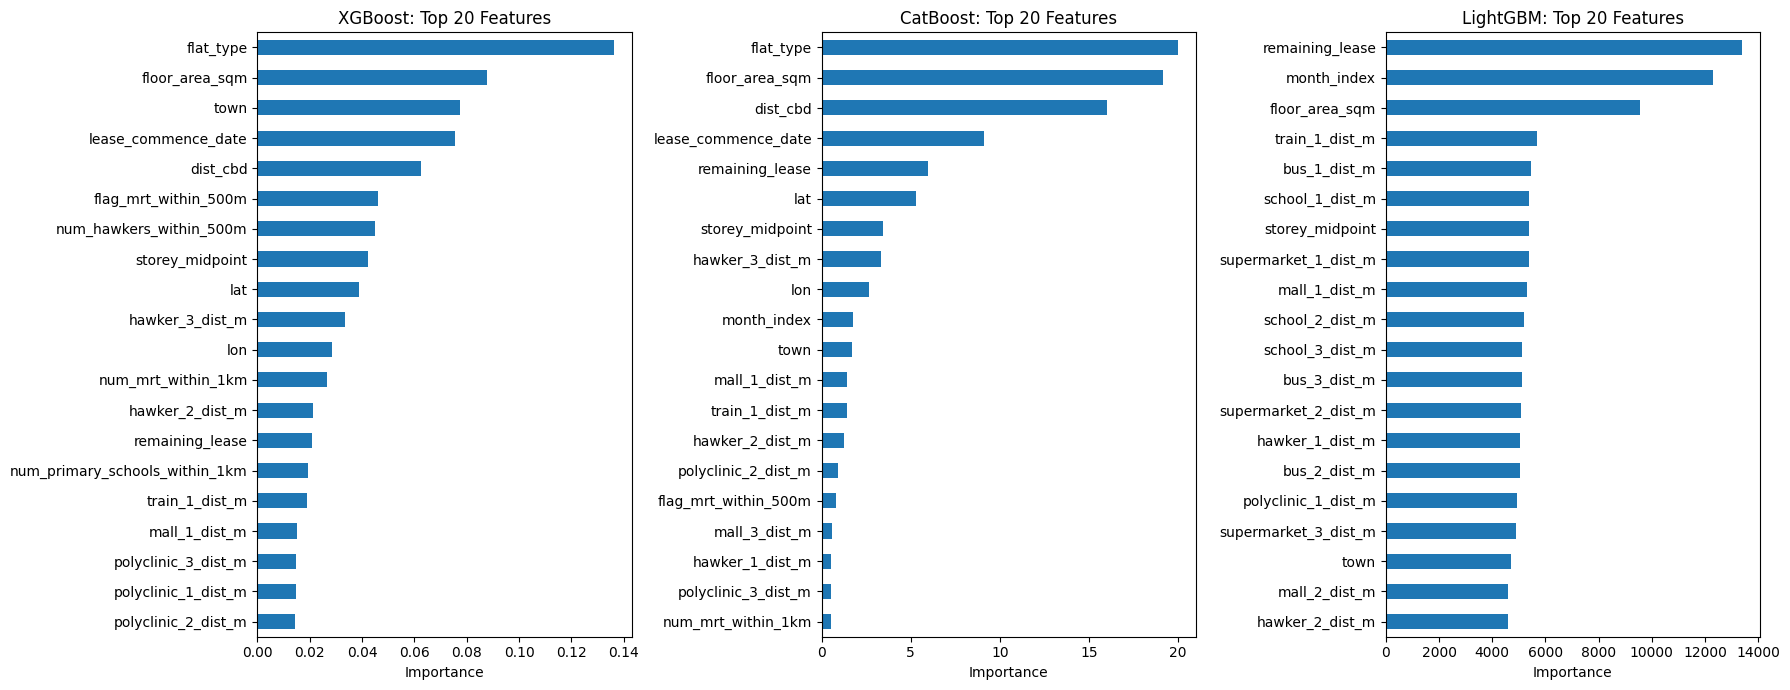

In [89]:
# Feature Importance (top 20)
feature_names_raw = X_train_raw.columns.tolist()
feature_names_lgb = X_train_lgb.columns.tolist()
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_names_raw).sort_values(ascending=False)
cb_imp = pd.Series(cb_model.get_feature_importance(), index=feature_names_raw).sort_values(ascending=False)
lgb_imp = pd.Series(lgb_model.feature_importances_, index=feature_names_lgb).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, imp, title in zip(axes, 
                          [xgb_imp, cb_imp, lgb_imp],
                          ["XGBoost", "CatBoost", "LightGBM"]):
    imp.head(20).plot(kind="barh", ax=ax)
    ax.set_title(f"{title}: Top 20 Features")
    ax.invert_yaxis(); ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [90]:
# Final Comparison Tables
results_all = [
    res_global_median, res_strat_median,
    res_lr,
    res_rf,
    res_lgb_sym, res_lgb,
    res_xgb_sym, res_xgb,
    res_cb_sym, res_cb,
    res_ens_b,
    *([res_ens_c] if res_ens_c is not None else []),
    res_ens_opt
]

summary = pd.DataFrame(results_all).set_index("name")

print(f"\n=== Sorted by Asymmetric Loss ===")
print(summary.sort_values("Lin-Lin").to_string(float_format=lambda x: f"{x:,.2f}"))

print(f"\n=== Sorted by Symmetric Loss ===")
print(summary.sort_values("MAE_nominal").to_string(float_format=lambda x: f"{x:,.2f}"))


=== Sorted by Asymmetric Loss ===
                                        Lin-Lin  Coverage  MAE_nominal       MAE      RMSE  MAPE
name                                                                                            
Ensemble (boosting, equal weights)     4,767.87      0.76    28,175.57 14,319.12 19,450.21  4.52
Ensemble (optimised weights)           4,769.50      0.76    28,220.99 14,342.40 19,473.99  4.53
Ensemble (boosting+RF, equal weights)  4,802.33      0.72    26,754.97 13,595.21 18,685.89  4.29
CatBoost (Asymmetric)                  4,845.76      0.76    28,586.12 14,530.36 19,783.74  4.57
LightGBM (Asymmetric)                  4,875.81      0.74    28,298.88 14,379.74 19,624.37  4.53
XGBoost (Asymmetric)                   4,881.82      0.76    28,820.59 14,646.82 19,897.25  4.64
XGBoost (Symmetric)                    5,234.45      0.59    23,498.61 11,942.41 16,742.08  3.72
LightGBM (Symmetric)                   5,238.96      0.60    23,728.09 12,055.57 16,909.49  

In [100]:
# Confidence intervals 

MODEL_KEY_MAP = {"LightGBM": "lgbm", "XGBoost": "xgb", "CatBoost": "cb"}

ci_offsets = {
    "ensemble": {                                           
        "p025_real": float(np.percentile(y_test.values - opt_pred, 2.5)),
        "p975_real": float(np.percentile(y_test.values - opt_pred, 97.5)),
    },
    "ensemble_equal": {                                   
        "p025_real": float(np.percentile(y_test.values - equal_pred, 2.5)),
        "p975_real": float(np.percentile(y_test.values - equal_pred, 97.5)),
    },
}

# Per-model residuals
for model_name, pred in winners_pred.items():
    key = MODEL_KEY_MAP.get(model_name)
    if key:
        r = y_test.values - pred
        ci_offsets[key] = {"p025_real": float(np.percentile(r, 2.5)),
                           "p975_real": float(np.percentile(r, 97.5))}
        print(f"CI offsets stored for key {key}")

with open("../json_outputs/ci_offsets.json", "w") as f:
    json.dump(ci_offsets, f, indent=2)
print("Saved keys:", list(ci_offsets.keys()))

CI offsets stored for key lgbm
CI offsets stored for key xgb
CI offsets stored for key cb
Saved keys: ['ensemble', 'ensemble_equal', 'lgbm', 'xgb', 'cb']


In [101]:
# Save winner models + final ensemble weights
os.makedirs("../models", exist_ok=True)
winners_model["CatBoost"].save_model("../models/cb_model.cbm")
winners_model["XGBoost"].save_model("../models/xgb_model.ubj")
joblib.dump(winners_model["LightGBM"], "../models/lgb_model.joblib")
with zipfile.ZipFile("../models/lgb_model.zip", "w", zipfile.ZIP_DEFLATED, compresslevel=9) as zf:
    zf.write("../models/lgb_model.joblib", "lgb_model.joblib")
print(f"Original: {os.path.getsize('../models/lgb_model.joblib') / 1e6:.1f} MB")
print(f"Zipped: {os.path.getsize('../models/lgb_model.zip') / 1e6:.1f} MB")
print(f"Saved models: {list(winners_model.keys())}")
np.save("../models/ensemble_weights.npy", opt_weights)
print(f"Saved optimised weights: {opt_weights.round(3)} for {final_model_names}")
print(f"(Final/recommended model: {final_model_names}, weights: {final_weights.round(3)})")

Original: 15.0 MB
Zipped: 5.3 MB
Saved models: ['LightGBM', 'XGBoost', 'CatBoost']
Saved optimised weights: [0.252 0.401 0.347] for ['LightGBM', 'XGBoost', 'CatBoost']
(Final/recommended model: ['LightGBM', 'XGBoost', 'CatBoost'], weights: [0.333 0.333 0.333])
